In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r'C:\Users\SHYAM SASHANK\OneDrive\Desktop\Data_Science\Assginment_CSV\AirLineData2.csv',header=0, index_col=0, parse_dates=True)

In [4]:
df

,Passengers
Month,
Jan-95,112
Feb-95,118
Mar-95,132
Apr-95,129
May-95,121
...,...
Aug-02,405
Sep-02,355
Oct-02,306


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96 entries, Jan-95 to Dec-02
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Passengers  96 non-null     int64
dtypes: int64(1)
memory usage: 1.5+ KB


In [6]:
df.isnull()

,Passengers
Month,
Jan-95,False
Feb-95,False
Mar-95,False
Apr-95,False
May-95,False
...,...
Aug-02,False
Sep-02,False
Oct-02,False


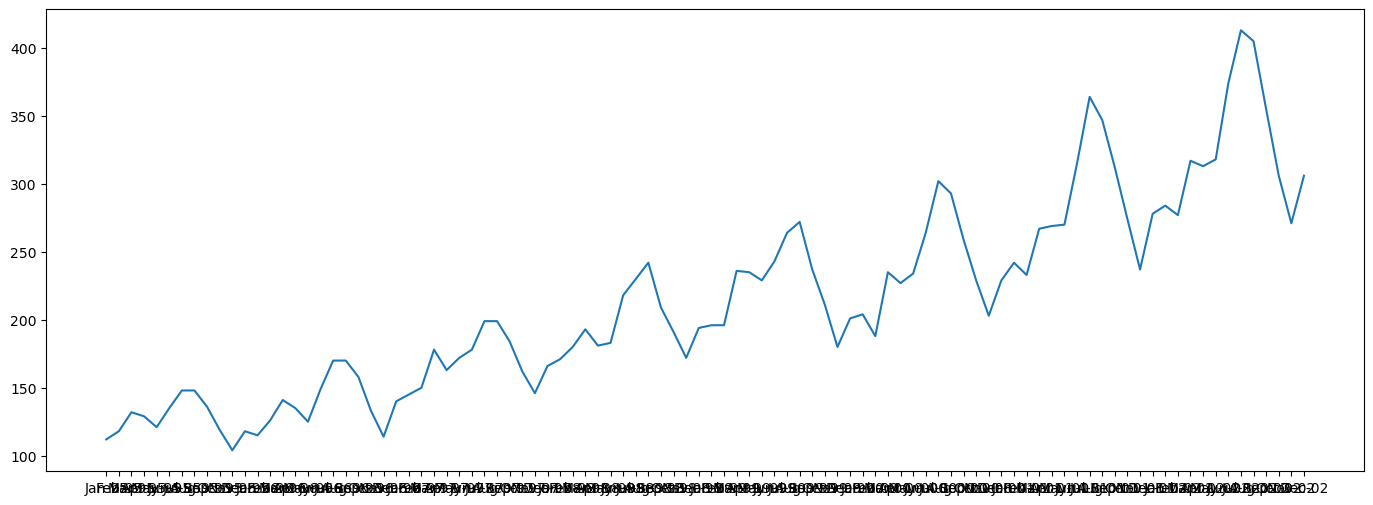

In [8]:
plt.figure(figsize=(17,6))
plt.plot(df)
plt.show()

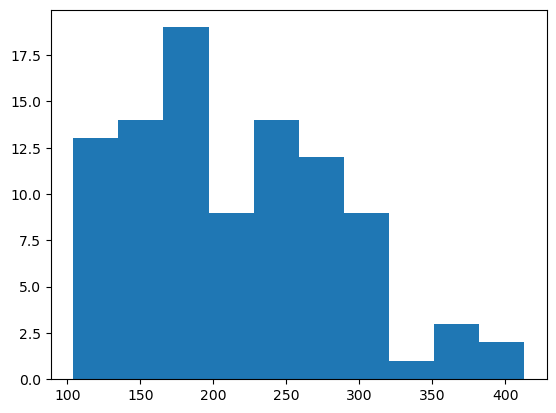

In [10]:
plt.hist(df.Passengers)
plt.show()

<AxesSubplot:ylabel='Density'>

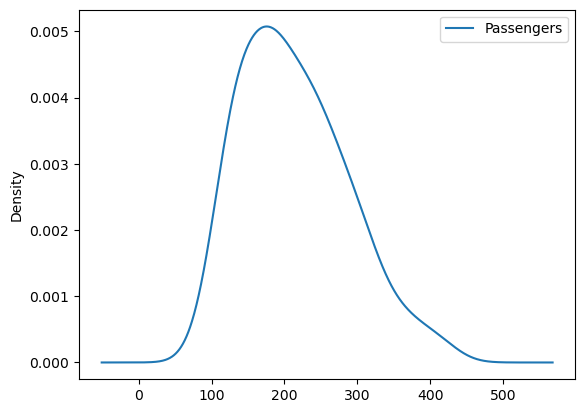

In [11]:
df.plot(kind='kde')

In [12]:
from scipy.stats import jarque_bera as jb
is_norm=jb(df["Passengers"])[1]
print(f"p value:{is_norm.round(2)}", ", df is Normal" if is_norm >0.05 else ", df is Non-Normal")

p value:0.04 , df is Non-Normal


In [17]:
# Train and test dataset are defined
size = int(len(df) * 0.67)
train, test = df[0:size], df[size:len(df)]
train


,Passengers
Month,
Jan-95,112
Feb-95,118
Mar-95,132
Apr-95,129
May-95,121
...,...
Dec-99,201
Jan-00,204
Feb-00,188


In [18]:
test

,Passengers
Month,
May-00,234
Jun-00,264
Jul-00,302
Aug-00,293
Sep-00,259
Oct-00,229
Nov-00,203
Dec-00,229
Jan-01,242


In [21]:
# Augmented Dickey-Fuller (ADF) test  here the ADF is import to check the dataset is stationary or not

from statsmodels.tsa.stattools import adfuller

# Now getting values of df dataset
values=df.values

# Now passing of the values to adfuller

result=adfuller(values)


In [24]:
print('Augmneted Dickey_fuller Statistic: %f' % result[0])
print('p-value: %f'  %result[1])

Augmneted Dickey_fuller Statistic: 1.340248
p-value: 0.996825


In [26]:
# printing the critical values at different alpha levels and the result of the test.
print('critical values at different levels:')
for k, v in result[4].items():
    print('\t%s: %.3f' % (k, v))
if (result[1] > 0.025):
    print("The time series is non-stationary")

critical values at different levels:
	1%: -3.512
	5%: -2.897
	10%: -2.586
The time series is non-stationary


p value:0.22488942647512633 , df is Non-Stationary


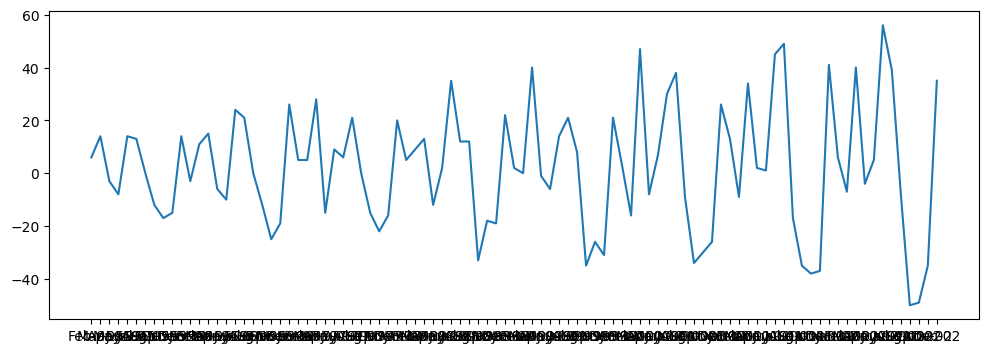

In [27]:
#De-trending with first order differencing

data1 = pd.DataFrame(df["Passengers"].diff())
de_trended = data1.dropna()
adf2 = adfuller(de_trended.values)[1]
print(f"p value:{adf2}", ", de_trended is Stationary" if adf2 <0.05 else ", df is Non-Stationary")
plt.figure(figsize = (12,4))
plt.plot(de_trended);
plt.show()

p value:3.503180236321534e-21 , data2 is Stationary


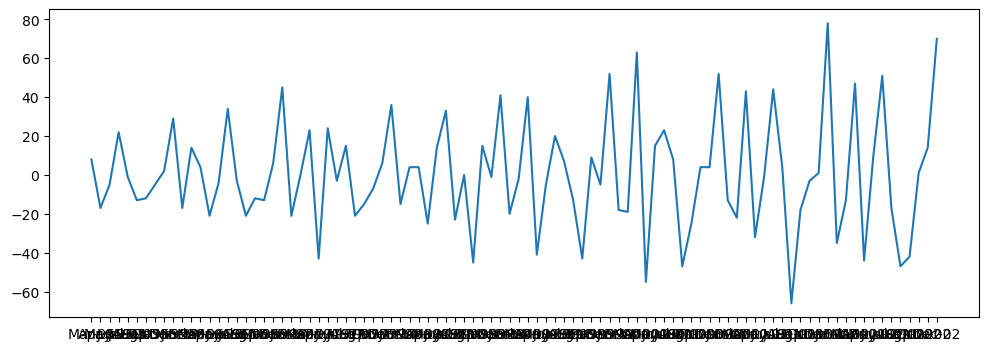

In [30]:
# Here, in the above the data is still non-stationary we have to do the second order differencing

data2=data1.diff().dropna()
adf3 = adfuller(data2.values)[1]
print(f"p value:{adf3}", ", data2 is Stationary" if adf3 <0.05 else ", df is Non-Stationary")
plt.figure(figsize = (12,4))
plt.plot(data2);
plt.show()

# Here the data1 is non stationary so the second order differencing is done

C:\Users\SHYAM SASHANK\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


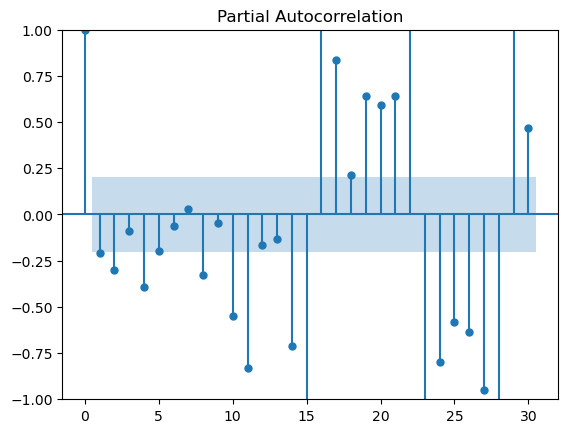

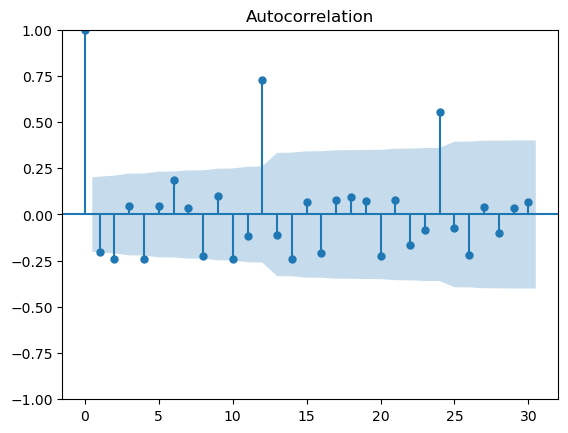

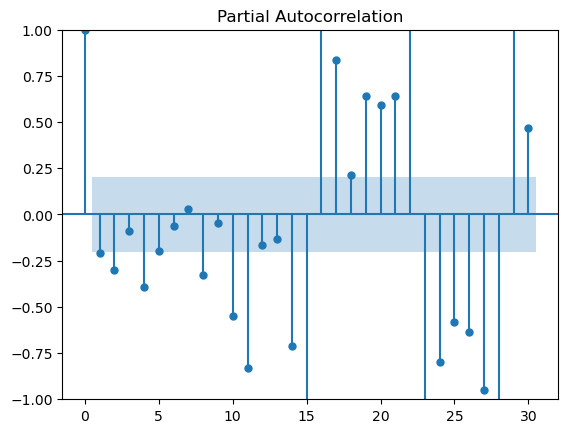

In [31]:
import statsmodels.graphics.tsaplots as tsa_plots
tsa_plots.plot_acf(data2.values,lags=30)
tsa_plots.plot_pacf(data2.values,lags=30)

In [32]:
# For finding the optimal p-values and q-values we use library call pmdarima

import pmdarima as pm
auto_arima_model = pm.auto_arima(df, seasonal=False, stepwise=True, suppress_warnings=True)
best_p, best_d, best_q = auto_arima_model.order
print(f"Best ARIMA order: ({best_p}, {best_d}, {best_q})")

#it is easy way to find out the p,q and d values

Best ARIMA order: (3, 1, 2)


In [33]:
from statsmodels.tsa.arima.model import ARIMA

In [45]:
# prepare data
X = train.values
X = X.astype('float32')

In [49]:
model=ARIMA(X, order=(3,1,2))
model_fit=model.fit()
forecast=model_fit.forecast(steps=32)
forecast

array([222.20988282, 217.93417209, 217.75392965, 216.72259658,
       217.71594485, 217.1482364 , 217.93988234, 217.35196613,
       217.93598197, 217.40322169, 217.88215572, 217.43481808,
       217.84025868, 217.46700719, 217.80889434, 217.49578615,
       217.78301564, 217.51990881, 217.76111434, 217.54005188,
       217.74265755, 217.55695469, 217.7271531 , 217.5711582 ,
       217.71413254, 217.58309164, 217.70319547, 217.59311623,
       217.69400781, 217.60153714, 217.68628977, 217.60861098])

In [50]:
test["forecast"]=forecast
test

C:\Users\SHYAM SASHANK\AppData\Local\Temp\ipykernel_16660\430218791.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test["forecast"]=forecast


,Passengers,forecast
Month,,
May-00,234,222.209883
Jun-00,264,217.934172
Jul-00,302,217.753930
Aug-00,293,216.722597
Sep-00,259,217.715945
Oct-00,229,217.148236
Nov-00,203,217.939882
Dec-00,229,217.351966
Jan-01,242,217.935982


In [52]:
from sklearn.metrics import mean_squared_error
from math import sqrt 
rmse = sqrt(mean_squared_error(test.Passengers, forecast))
rmse

90.43933547455512

In [53]:
# Fitting the whole dataset

Y = df.values
Y = Y.astype('float32')
model1=ARIMA(Y, order=(3,1,2))
model_fit = model.fit()

C:\Users\SHYAM SASHANK\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


In [54]:
forecast=model_fit.forecast(steps=5)
forecast

array([222.20988282, 217.93417209, 217.75392965, 216.72259658,
       217.71594485])

In [55]:
forecastdata = pd.DataFrame()
forecastdata["forecasted_val"] = forecast

In [56]:
forecastdata

,forecasted_val
0,222.209883
1,217.934172
2,217.753930
3,216.722597
4,217.715945


In [57]:
passengers=pd.concat([df,forecastdata], ignore_index=True)
passengers

,Passengers,forecasted_val
0,112.0,NaN
1,118.0,NaN
2,132.0,NaN
3,129.0,NaN
4,121.0,NaN
...,...,...
96,NaN,222.209883
97,NaN,217.934172
98,NaN,217.753930
99,NaN,216.722597


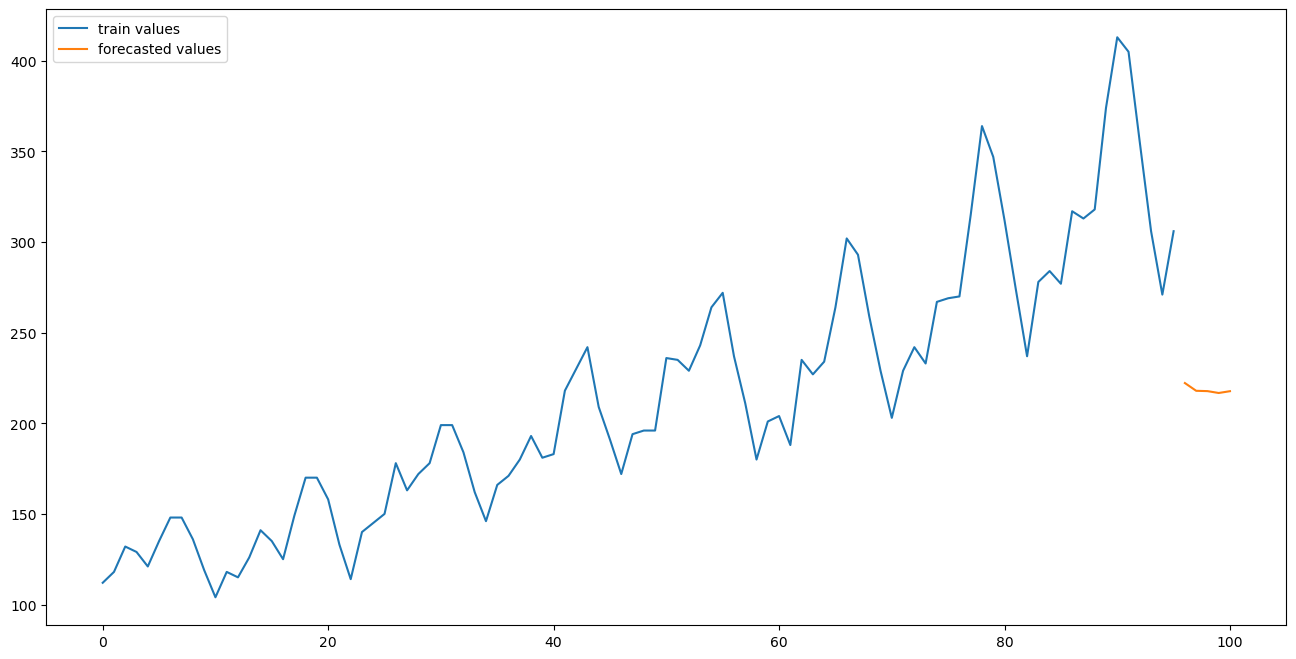

In [59]:
plt.figure(figsize=(16,8))

plt.plot(passengers["Passengers"], label='train values')
plt.plot(passengers["forecasted_val"], label="forecasted values")
plt.legend(loc='best')
plt.show()